In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [6]:
df = pd.read_csv("/content/sample_data/shopify_stock.csv")
df

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800000,2.874000,2.411000,2.568000,2.568000,123039000
1,2015-05-22 00:00:00-04:00,2.607000,3.110000,2.600000,2.831000,2.831000,28412000
2,2015-05-26 00:00:00-04:00,2.980000,3.034000,2.908000,2.965000,2.965000,8202000
3,2015-05-27 00:00:00-04:00,3.067000,3.081000,2.700000,2.750000,2.750000,7976000
4,2015-05-28 00:00:00-04:00,2.755000,2.774000,2.648000,2.745000,2.745000,4000000
...,...,...,...,...,...,...,...
2464,2025-03-10 00:00:00-04:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300
2465,2025-03-11 00:00:00-04:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100
2466,2025-03-12 00:00:00-04:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900
2467,2025-03-13 00:00:00-04:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400


In [7]:
display(df.head())

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


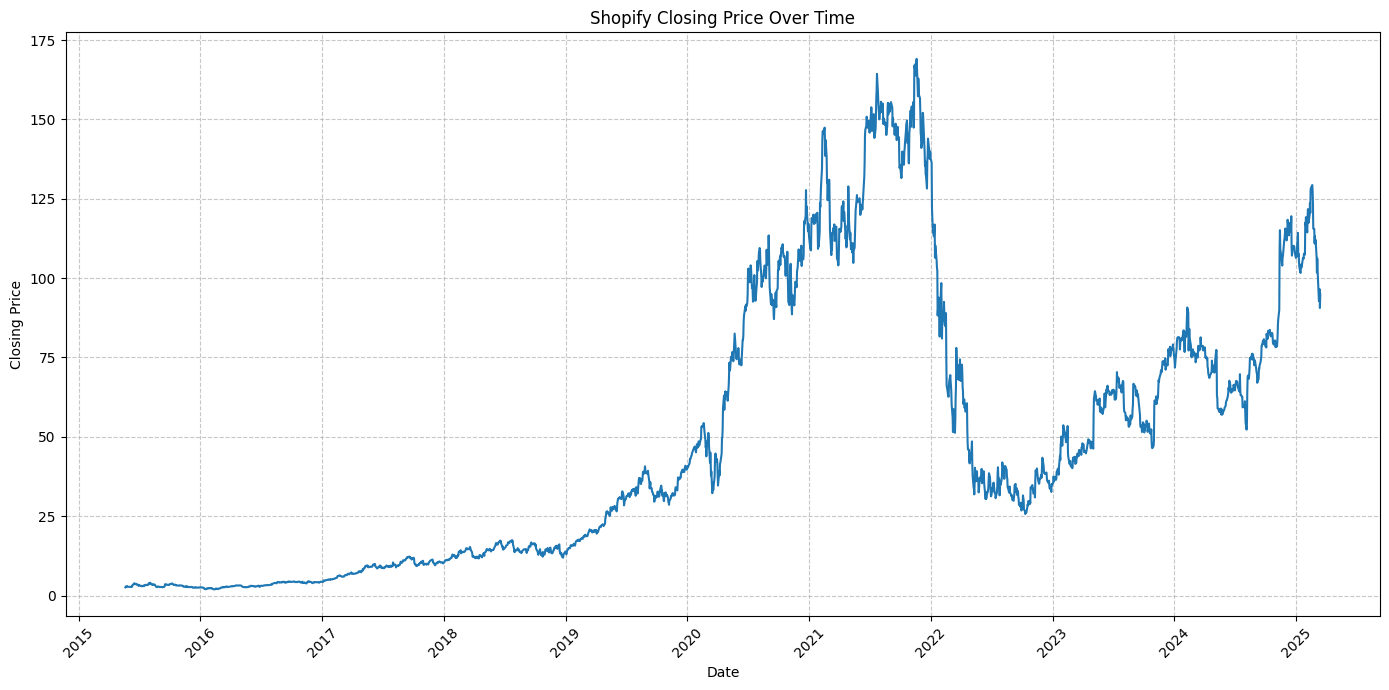

In [11]:
df['date'] = pd.to_datetime(df['date'], utc=True)

fig = plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='close', data=df)
plt.title('Shopify Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

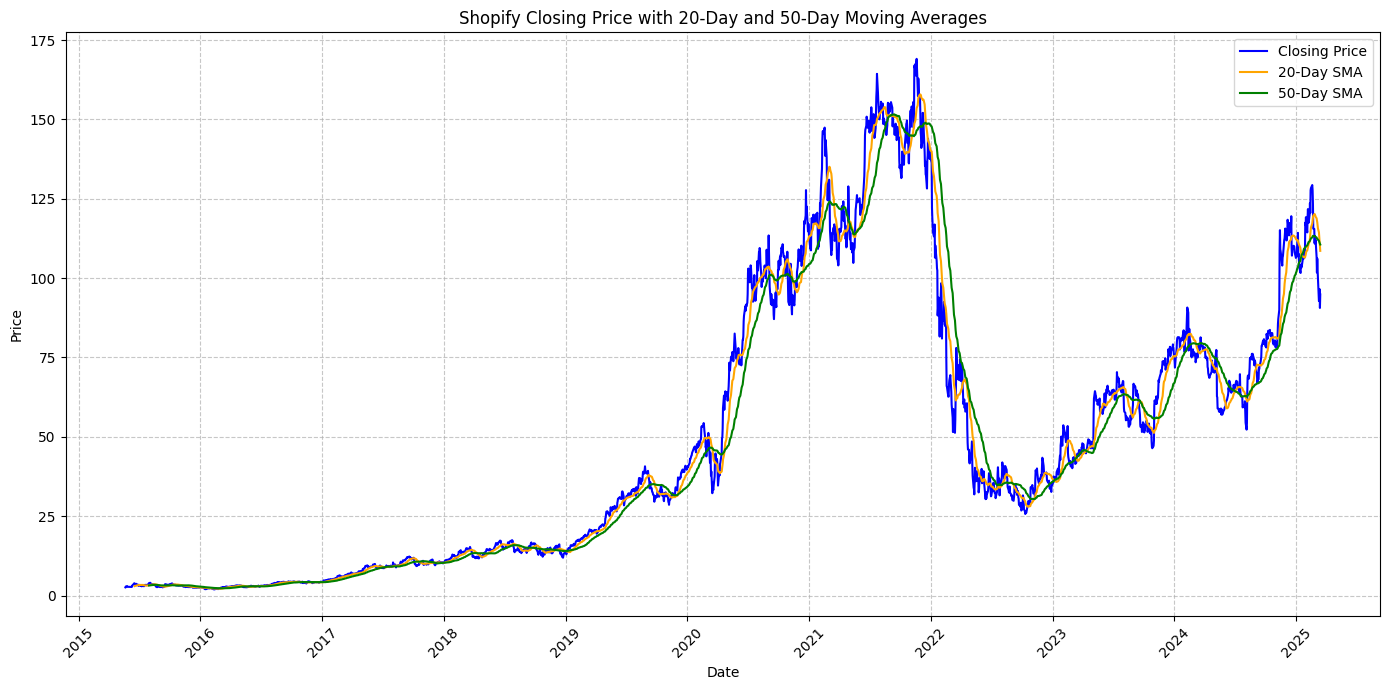

In [14]:

df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
fig = plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='close', data=df, label='Closing Price', color='blue')
sns.lineplot(x='date', y='SMA_20', data=df, label='20-Day SMA', color='orange')
sns.lineplot(x='date', y='SMA_50', data=df, label='50-Day SMA', color='green')

plt.title('Shopify Closing Price with 20-Day and 50-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

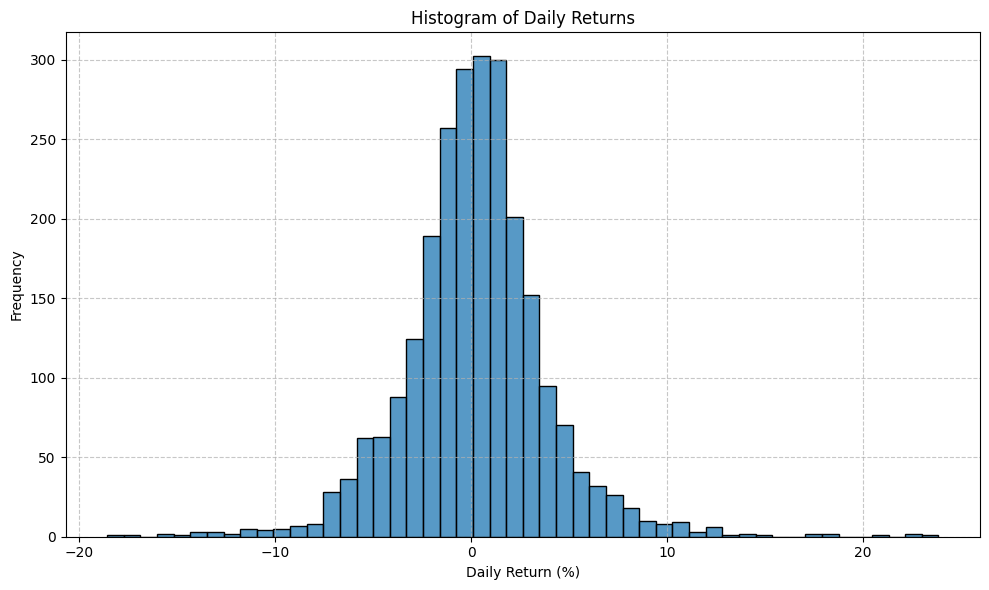

In [25]:

df['Daily_Return'] = df['close'].pct_change() * 100
df_returns = df.dropna(subset=['Daily_Return'])
fig = plt.figure(figsize=(10, 6))
sns.histplot(df_returns['Daily_Return'], bins=50, kde=False)
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

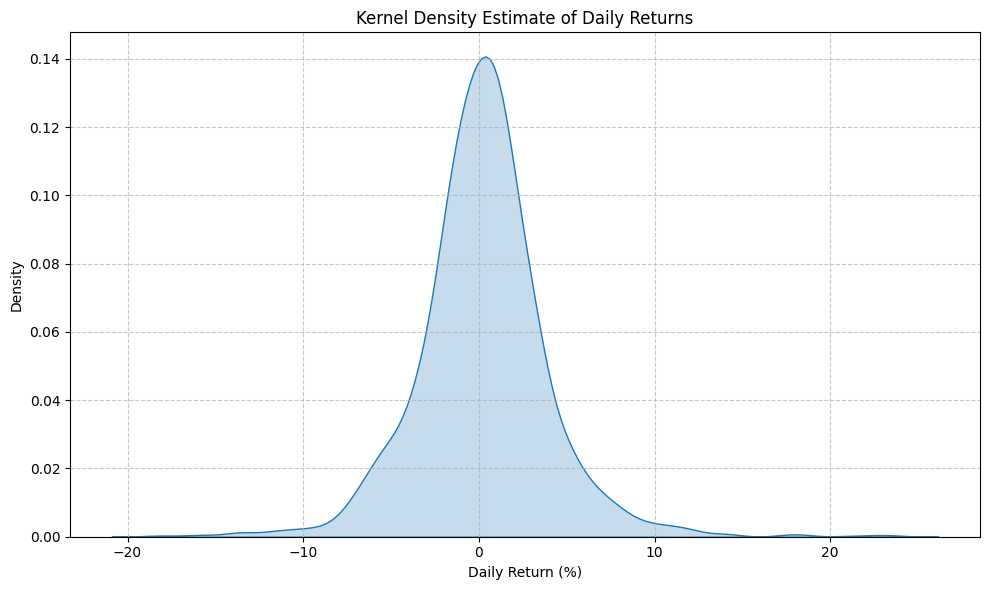

In [28]:

df['Daily_Return'] = df['close'].pct_change() * 100
df_returns = df.dropna(subset=['Daily_Return'])
fig = plt.figure(figsize=(10, 6))
sns.kdeplot(df_returns['Daily_Return'], fill=True)
plt.title('Kernel Density Estimate of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()